# Sen1Floods11 — Exploratory Data Analysis
### Flood Extent Mapping from Satellite Imagery

**Dataset:** Sen1Floods11 — 11 flood events globally, Sentinel-1 SAR + Sentinel-2 optical  
**Goal:** Understand the data before building a segmentation model

---
**EDA Sections:**
1. Imports & Paths
2. Dataset Overview (chip counts per country/split)
3. Image Properties (shape, bands, CRS, resolution)
4. Visualize Sample Chips (S1, S2, Label, JRC)
5. Label Distribution (flood / non-flood / invalid)
6. Band Statistics (mean, std, min, max)
7. Class Imbalance Analysis
8. Geographic Coverage

## 1. Imports & Paths

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import show
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path("/Users/hardikkamboj/Desktop/UMD/605/group_project/Sen1Floods11/v1.1/data")

HAND = BASE / "flood_events" / "HandLabeled"
WEAK = BASE / "flood_events" / "WeaklyLabeled"
PERM = BASE / "perm_water"

# HandLabeled subfolders
S1_HAND    = HAND / "S1Hand"          # Sentinel-1 SAR  (2 bands: VV, VH)
S2_HAND    = HAND / "S2Hand"          # Sentinel-2 optical (13 bands)
LABEL_HAND = HAND / "LabelHand"       # Ground truth masks
JRC_HAND   = HAND / "JRCWaterHand"    # JRC permanent water
OTSU_HAND  = HAND / "S1OtsuLabelHand" # Otsu auto-label on S1

# WeaklyLabeled subfolders
S1_WEAK    = WEAK / "S1Weak"
S2_WEAK    = WEAK / "S2Weak"
OTSU_WEAK  = WEAK / "S1OtsuLabelWeak"
IDX_WEAK   = WEAK / "S2IndexLabelWeak"

print("Paths set up successfully ✓")

Paths set up successfully ✓


## 2. Dataset Overview — Chip Counts per Country & Split

In [2]:
def count_by_country(folder, suffix):
    """Count chips per country in a given folder."""
    counts = Counter()
    for f in sorted(folder.glob(f"*{suffix}.tif")):
        country = f.stem.split("_")[0]
        counts[country] += 1
    return counts

hand_counts = count_by_country(S1_HAND, "S1Hand")
weak_counts = count_by_country(S1_WEAK, "S1Weak")

# Summary table
df_hand = pd.DataFrame(hand_counts.items(), columns=["Country", "HandLabeled"]).sort_values("Country")
df_weak = pd.DataFrame(weak_counts.items(), columns=["Country", "WeaklyLabeled"]).sort_values("Country")
df = pd.merge(df_hand, df_weak, on="Country", how="outer").fillna(0).astype({"HandLabeled": int, "WeaklyLabeled": int})
df["Total"] = df["HandLabeled"] + df["WeaklyLabeled"]
df = df.sort_values("Total", ascending=False).reset_index(drop=True)

print(f"{'='*45}")
print(f"  HandLabeled chips  : {df['HandLabeled'].sum():>6}")
print(f"  WeaklyLabeled chips: {df['WeaklyLabeled'].sum():>6}")
print(f"  Total chips        : {df['Total'].sum():>6}")
print(f"{'='*45}")
print(f"  Unique countries   : {len(df)}")
print(f"{'='*45}\n")
df

  HandLabeled chips  :    446
  WeaklyLabeled chips:   4384
  Total chips        :   4830
  Unique countries   : 12



,Country,HandLabeled,WeaklyLabeled,Total
0,Mekong,30,1353,1383
1,USA,69,486,555
2,India,68,467,535
3,Colombia,0,534,534
4,Paraguay,67,316,383
5,Pakistan,28,249,277
6,Bolivia,15,224,239
7,Ghana,53,181,234
8,Sri-Lanka,42,190,232
9,Spain,30,146,176


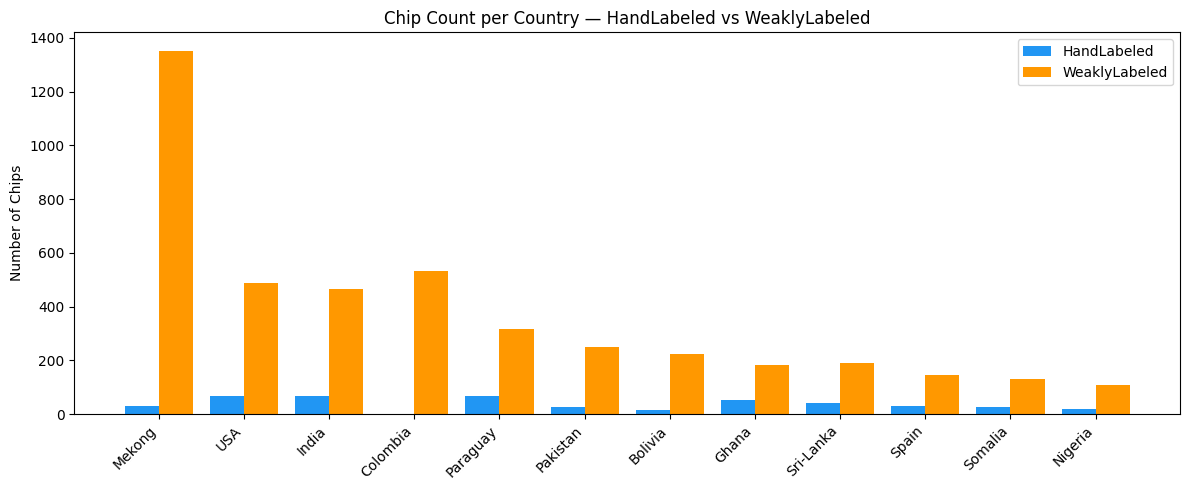

In [3]:
# Bar chart: chips per country (HandLabeled vs WeaklyLabeled)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df))
width = 0.4
ax.bar(x - width/2, df["HandLabeled"],  width, label="HandLabeled",   color="#2196F3")
ax.bar(x + width/2, df["WeaklyLabeled"], width, label="WeaklyLabeled", color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(df["Country"], rotation=45, ha="right")
ax.set_ylabel("Number of Chips")
ax.set_title("Chip Count per Country — HandLabeled vs WeaklyLabeled")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Image Properties — Shape, Bands, Resolution, CRS

In [4]:
def inspect_image(path):
    """Print key metadata of a GeoTIFF."""
    with rasterio.open(path) as src:
        return {
            "file"      : path.name,
            "shape"     : (src.count, src.height, src.width),
            "dtype"     : src.dtypes[0],
            "crs"       : str(src.crs),
            "res (m)"   : round(src.res[0], 2),
            "nodata"    : src.nodata,
            "bounds"    : src.bounds,
        }

# Pick one Bolivia chip as representative
chip_id = "Bolivia_103757"
samples = {
    "S1 (SAR)"     : S1_HAND    / f"{chip_id}_S1Hand.tif",
    "S2 (optical)" : S2_HAND    / f"{chip_id}_S2Hand.tif",
    "Label"        : LABEL_HAND / f"{chip_id}_LabelHand.tif",
    "JRC Water"    : JRC_HAND   / f"{chip_id}_JRCWaterHand.tif",
    "Otsu Label"   : OTSU_HAND  / f"{chip_id}_S1OtsuLabelHand.tif",
}

rows = []
for name, path in samples.items():
    info = inspect_image(path)
    info["type"] = name
    rows.append(info)

df_props = pd.DataFrame(rows)[["type","file","shape","dtype","crs","res (m)","nodata"]]
df_props

,type,file,shape,dtype,crs,res (m),nodata
0,S1 (SAR),Bolivia_103757_S1Hand.tif,"(2, 512, 512)",float32,EPSG:4326,0.0,NaN
1,S2 (optical),Bolivia_103757_S2Hand.tif,"(13, 512, 512)",int16,EPSG:4326,0.0,0.0
2,Label,Bolivia_103757_LabelHand.tif,"(1, 512, 512)",int16,EPSG:4326,0.0,NaN
3,JRC Water,Bolivia_103757_JRCWaterHand.tif,"(1, 512, 512)",uint8,EPSG:4326,0.0,NaN
4,Otsu Label,Bolivia_103757_S1OtsuLabelHand.tif,"(1, 512, 512)",int16,EPSG:4326,0.0,-1.0


## 4. Visualize Sample Chips — S1, S2, Label, JRC Water

In [12]:
vv = read_band(s1_path, 1)

(array([3.0000e+00, 1.7000e+01, 1.1400e+02, 1.4060e+03, 8.8920e+03,
        2.0145e+04, 1.6083e+04, 2.5085e+04, 2.8218e+04, 1.6600e+03]),
 array([-40.82144165, -36.80835738, -32.79527311, -28.78218884,
        -24.76910458, -20.75602031, -16.74293604, -12.72985177,
         -8.7167675 ,  -4.70368323,  -0.69059896]),
 <BarContainer object of 10 artists>)

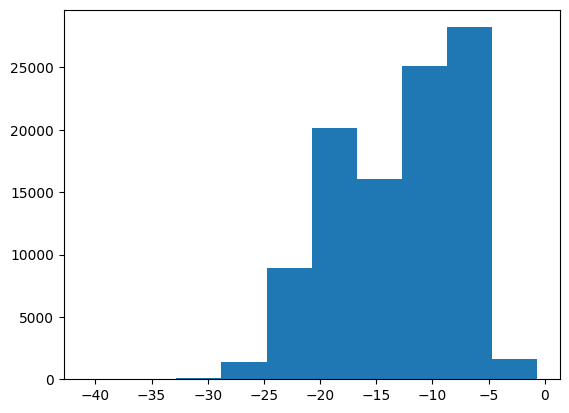

In [16]:
plt.hist(np.ravel(vv))

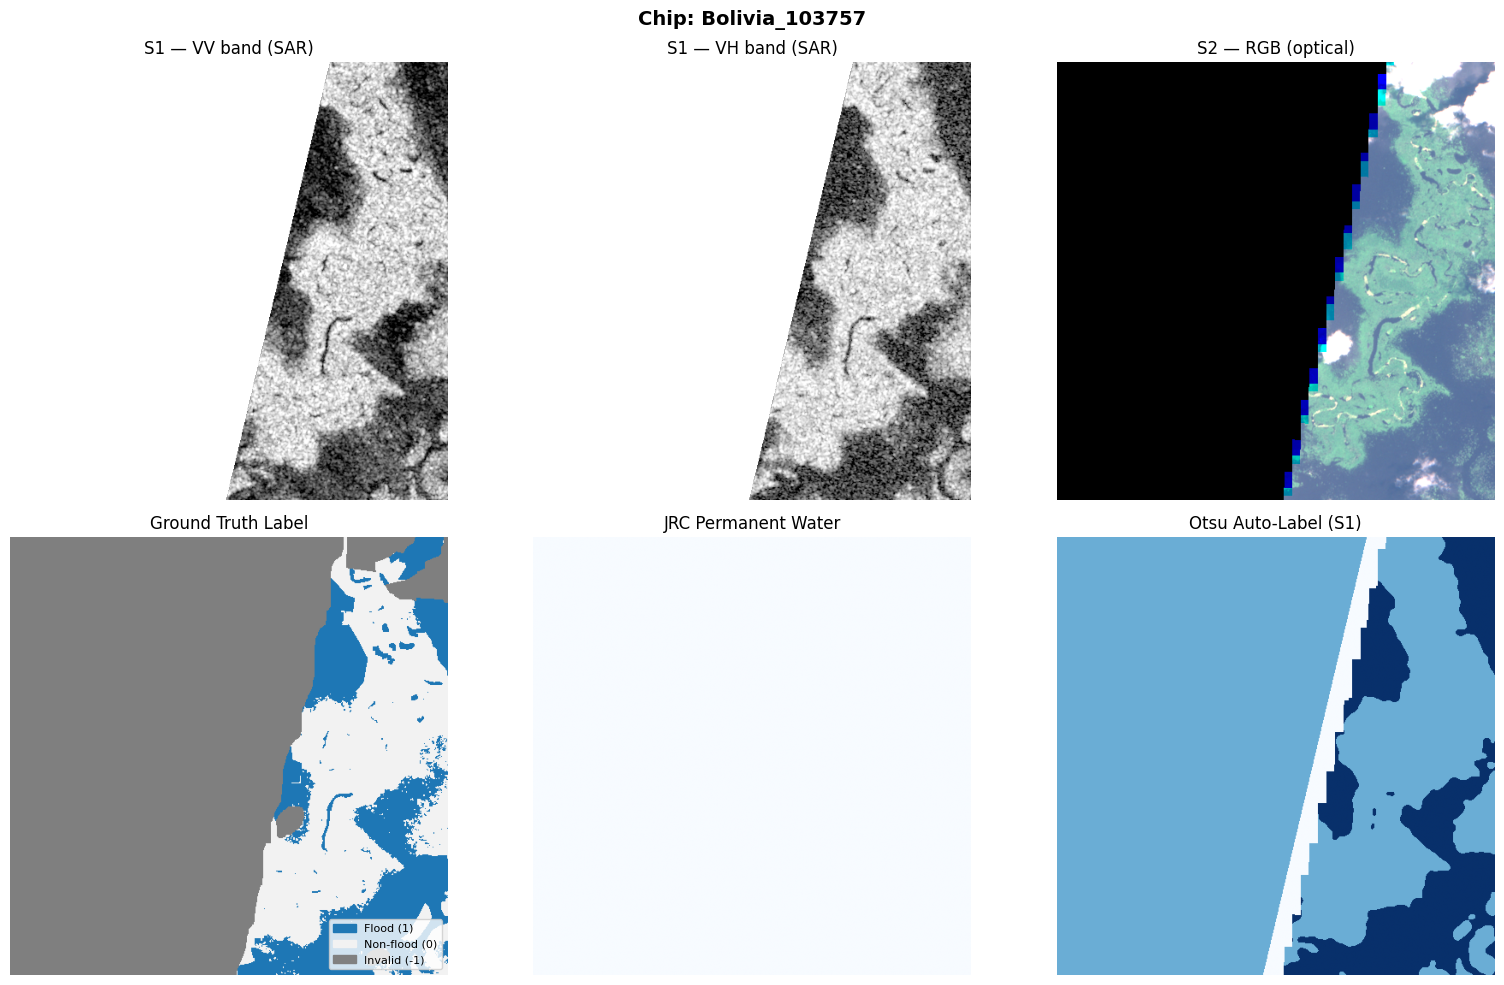

In [5]:
def read_band(path, band=1):
    with rasterio.open(path) as src:
        return src.read(band).astype(float)

def percentile_stretch(arr, pct_low=2, pct_high=98):
    """Contrast stretch using percentile clipping for better visualization."""
    lo, hi = np.nanpercentile(arr, pct_low), np.nanpercentile(arr, pct_high)
    stretched = np.clip((arr - lo) / (hi - lo + 1e-9), 0, 1)
    return stretched

chip_id = "Bolivia_103757"

s1_path    = S1_HAND    / f"{chip_id}_S1Hand.tif"
s2_path    = S2_HAND    / f"{chip_id}_S2Hand.tif"
label_path = LABEL_HAND / f"{chip_id}_LabelHand.tif"
jrc_path   = JRC_HAND   / f"{chip_id}_JRCWaterHand.tif"
otsu_path  = OTSU_HAND  / f"{chip_id}_S1OtsuLabelHand.tif"

# Read data
s1_vv  = percentile_stretch(read_band(s1_path, 1))   # VV polarisation
s1_vh  = percentile_stretch(read_band(s1_path, 2))   # VH polarisation
label  = read_band(label_path, 1)
jrc    = read_band(jrc_path,   1)
otsu   = read_band(otsu_path,  1)

# S2 RGB: bands 4 (Red), 3 (Green), 2 (Blue)
with rasterio.open(s2_path) as src:
    r = percentile_stretch(src.read(4).astype(float))
    g = percentile_stretch(src.read(3).astype(float))
    b = percentile_stretch(src.read(2).astype(float))
s2_rgb = np.stack([r, g, b], axis=-1)

# Label colour map: -1=invalid(grey), 0=non-flood(white), 1=flood(blue)
label_colors = np.zeros((*label.shape, 3))
label_colors[label == 0]  = [0.95, 0.95, 0.95]   # non-flood → light grey
label_colors[label == 1]  = [0.12, 0.47, 0.71]   # flood → blue
label_colors[label == -1] = [0.50, 0.50, 0.50]   # invalid → mid grey

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"Chip: {chip_id}", fontsize=14, fontweight="bold")

axes[0,0].imshow(s1_vv, cmap="gray"); axes[0,0].set_title("S1 — VV band (SAR)")
axes[0,1].imshow(s1_vh, cmap="gray"); axes[0,1].set_title("S1 — VH band (SAR)")
axes[0,2].imshow(s2_rgb);             axes[0,2].set_title("S2 — RGB (optical)")
axes[1,0].imshow(label_colors);       axes[1,0].set_title("Ground Truth Label")
axes[1,1].imshow(jrc, cmap="Blues");  axes[1,1].set_title("JRC Permanent Water")
axes[1,2].imshow(otsu, cmap="Blues"); axes[1,2].set_title("Otsu Auto-Label (S1)")

# Legend for label plot
patches = [
    mpatches.Patch(color=[0.12,0.47,0.71], label="Flood (1)"),
    mpatches.Patch(color=[0.95,0.95,0.95], label="Non-flood (0)"),
    mpatches.Patch(color=[0.50,0.50,0.50], label="Invalid (-1)"),
]
axes[1,0].legend(handles=patches, loc="lower right", fontsize=8)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

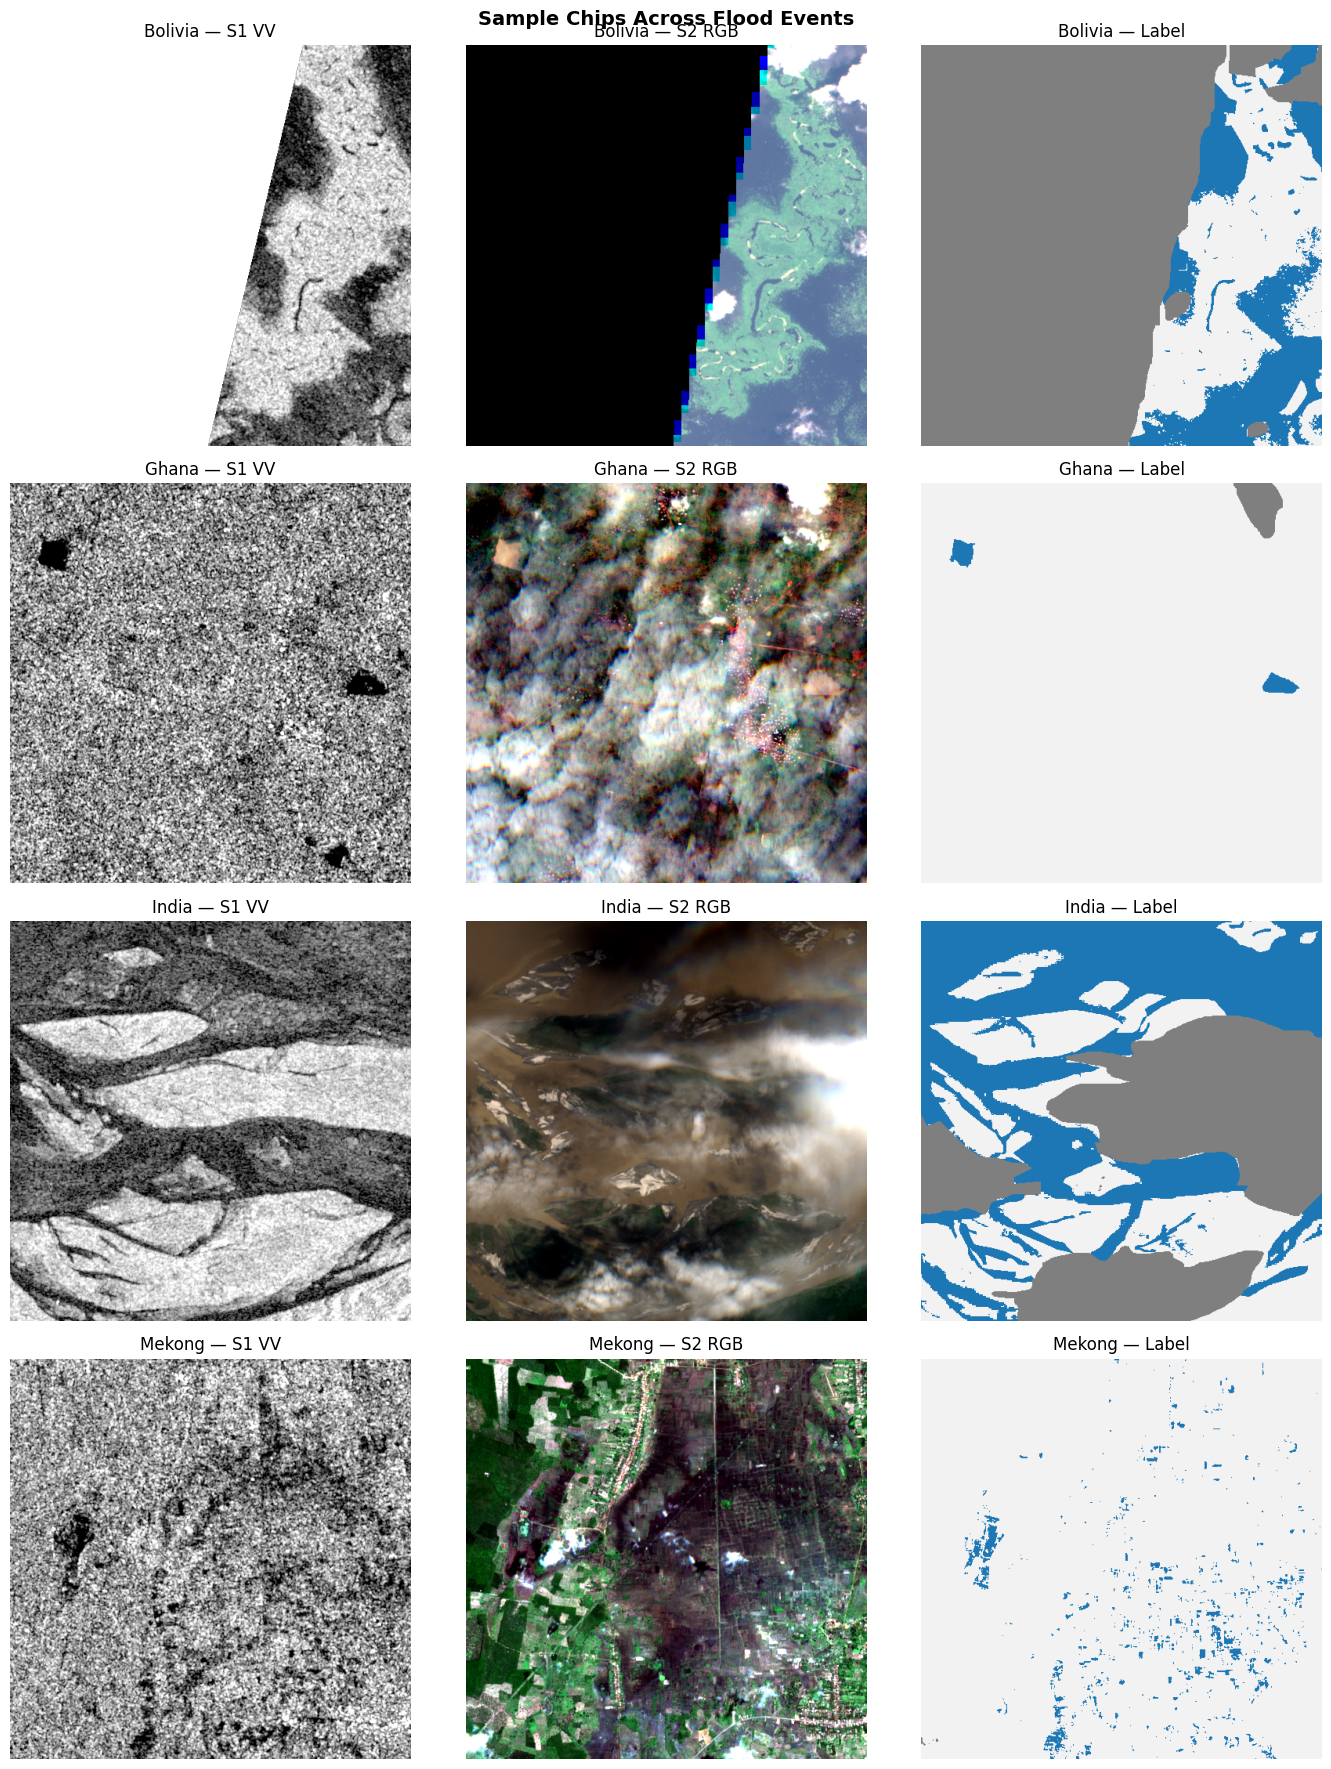

In [6]:
# Visualize a few different countries side by side (S1 VV + Label)
sample_chips = [
    ("Bolivia",   "Bolivia_103757"),
    ("India",     "India_0"),
    ("Nigeria",   "Nigeria_0"),
    ("Spain",     "Spain_0"),
]

# Find valid chip IDs for each country automatically
def get_first_chip(country, folder, suffix):
    chips = sorted(folder.glob(f"{country}_*{suffix}.tif"))
    return chips[0] if chips else None

fig, axes = plt.subplots(4, 3, figsize=(14, 18))
fig.suptitle("Sample Chips Across Flood Events", fontsize=14, fontweight="bold")

countries = list(hand_counts.keys())[:4]  # take first 4 countries

for row_idx, country in enumerate(countries):
    s1_file    = get_first_chip(country, S1_HAND,    "S1Hand")
    label_file = get_first_chip(country, LABEL_HAND, "LabelHand")
    s2_file    = get_first_chip(country, S2_HAND,    "S2Hand")

    if not (s1_file and label_file and s2_file):
        continue

    vv  = percentile_stretch(read_band(s1_file, 1))
    lbl = read_band(label_file, 1)

    lbl_rgb = np.zeros((*lbl.shape, 3))
    lbl_rgb[lbl == 0]  = [0.95, 0.95, 0.95]
    lbl_rgb[lbl == 1]  = [0.12, 0.47, 0.71]
    lbl_rgb[lbl == -1] = [0.50, 0.50, 0.50]

    with rasterio.open(s2_file) as src:
        rgb = np.stack([
            percentile_stretch(src.read(4).astype(float)),
            percentile_stretch(src.read(3).astype(float)),
            percentile_stretch(src.read(2).astype(float)),
        ], axis=-1)

    axes[row_idx, 0].imshow(vv, cmap="gray")
    axes[row_idx, 0].set_title(f"{country} — S1 VV")
    axes[row_idx, 1].imshow(rgb)
    axes[row_idx, 1].set_title(f"{country} — S2 RGB")
    axes[row_idx, 2].imshow(lbl_rgb)
    axes[row_idx, 2].set_title(f"{country} — Label")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Label Distribution — Flood / Non-Flood / Invalid Pixels

In [7]:
# Aggregate pixel counts across ALL HandLabeled chips
print("Scanning all HandLabeled chips for pixel statistics...")
print("(This may take ~1 min for 446 chips)\n")

total_flood, total_nonflood, total_invalid = 0, 0, 0
chip_flood_pcts = []

label_files = sorted(LABEL_HAND.glob("*LabelHand.tif"))

for lf in label_files:
    with rasterio.open(lf) as src:
        lbl = src.read(1)
    n_flood    = np.sum(lbl == 1)
    n_nonflood = np.sum(lbl == 0)
    n_invalid  = np.sum(lbl == -1)
    total      = n_flood + n_nonflood + n_invalid

    total_flood    += n_flood
    total_nonflood += n_nonflood
    total_invalid  += n_invalid

    valid = n_flood + n_nonflood
    chip_flood_pcts.append(n_flood / valid * 100 if valid > 0 else 0)

grand_total = total_flood + total_nonflood + total_invalid

print(f"{'Class':<15} {'Pixels':>15} {'Percentage':>12}")
print("-" * 45)
print(f"{'Flood (1)':<15} {total_flood:>15,} {total_flood/grand_total*100:>11.2f}%")
print(f"{'Non-flood (0)':<15} {total_nonflood:>15,} {total_nonflood/grand_total*100:>11.2f}%")
print(f"{'Invalid (-1)':<15} {total_invalid:>15,} {total_invalid/grand_total*100:>11.2f}%")
print("-" * 45)
print(f"{'Total':<15} {grand_total:>15,}")

Scanning all HandLabeled chips for pixel statistics...
(This may take ~1 min for 446 chips)

Class                    Pixels   Percentage
---------------------------------------------
Flood (1)            10,705,605        9.16%
Non-flood (0)        90,277,709       77.22%
Invalid (-1)         15,932,910       13.63%
---------------------------------------------
Total               116,916,224


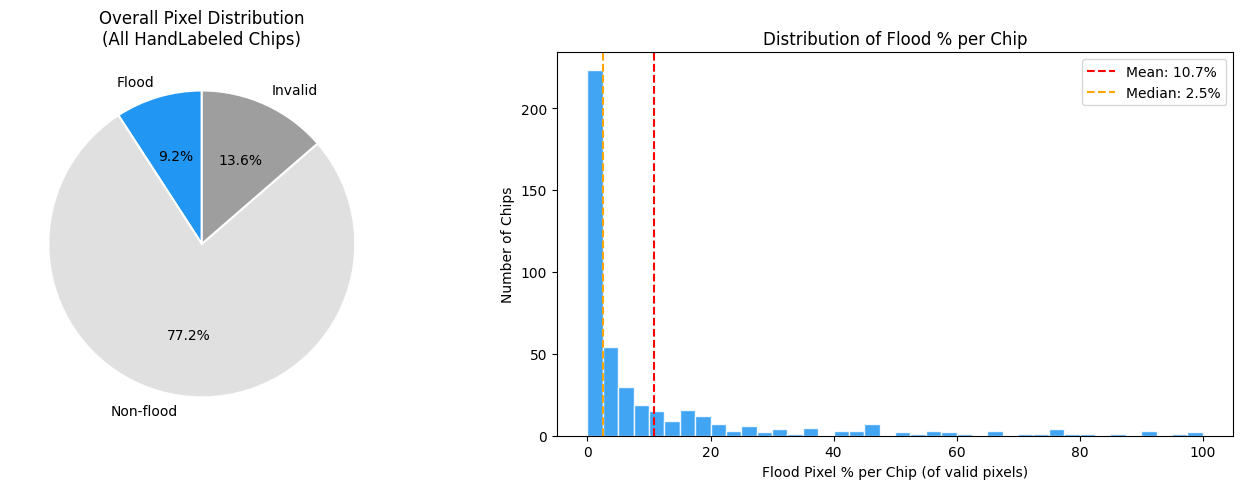


Chips with >50% flood pixels : 27
Chips with  0% flood pixels  : 52
Mean flood % per chip        : 10.7%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — overall pixel distribution
axes[0].pie(
    [total_flood, total_nonflood, total_invalid],
    labels=["Flood", "Non-flood", "Invalid"],
    colors=["#2196F3", "#E0E0E0", "#9E9E9E"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[0].set_title("Overall Pixel Distribution\n(All HandLabeled Chips)", fontsize=12)

# Histogram — flood % per chip
axes[1].hist(chip_flood_pcts, bins=40, color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].axvline(np.mean(chip_flood_pcts), color="red",    linestyle="--", label=f"Mean: {np.mean(chip_flood_pcts):.1f}%")
axes[1].axvline(np.median(chip_flood_pcts), color="orange", linestyle="--", label=f"Median: {np.median(chip_flood_pcts):.1f}%")
axes[1].set_xlabel("Flood Pixel % per Chip (of valid pixels)")
axes[1].set_ylabel("Number of Chips")
axes[1].set_title("Distribution of Flood % per Chip", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nChips with >50% flood pixels : {sum(p > 50 for p in chip_flood_pcts)}")
print(f"Chips with  0% flood pixels  : {sum(p == 0 for p in chip_flood_pcts)}")
print(f"Mean flood % per chip        : {np.mean(chip_flood_pcts):.1f}%")

## 6. Band Statistics — S1 (VV, VH) and S2 (selected bands)

In [9]:
# Sample 30 random chips to compute band statistics efficiently
import random
random.seed(42)

s1_files = sorted(S1_HAND.glob("*S1Hand.tif"))
s2_files = sorted(S2_HAND.glob("*S2Hand.tif"))
sample_n = 30

s1_sample = random.sample(s1_files, sample_n)
s2_sample = random.sample(s2_files, sample_n)

# S1 stats (2 bands: VV, VH)
s1_stats = {1: {"name":"VV", "vals":[]}, 2: {"name":"VH", "vals":[]}}
for f in s1_sample:
    with rasterio.open(f) as src:
        for b in [1, 2]:
            arr = src.read(b).astype(float).ravel()
            arr = arr[np.isfinite(arr)]
            s1_stats[b]["vals"].extend(arr.tolist())

# S2 band names (13 bands)
s2_band_names = ["B1","B2(Blue)","B3(Green)","B4(Red)","B5","B6","B7",
                 "B8(NIR)","B8A","B9","B10","B11(SWIR1)","B12(SWIR2)"]
s2_stats = {i+1: {"name": s2_band_names[i], "vals":[]} for i in range(13)}

for f in s2_sample:
    with rasterio.open(f) as src:
        for b in range(1, 14):
            arr = src.read(b).astype(float).ravel()
            arr = arr[np.isfinite(arr) & (arr > 0)]  # exclude nodata
            s2_stats[b]["vals"].extend(arr.tolist())

# Build summary dataframe
rows = []
for b, info in s1_stats.items():
    v = np.array(info["vals"])
    rows.append({"sensor":"S1", "band": info["name"],
                 "mean": v.mean(), "std": v.std(),
                 "min": v.min(), "max": v.max(),
                 "p5": np.percentile(v,5), "p95": np.percentile(v,95)})

for b, info in s2_stats.items():
    v = np.array(info["vals"])
    if len(v) == 0: continue
    rows.append({"sensor":"S2", "band": info["name"],
                 "mean": v.mean(), "std": v.std(),
                 "min": v.min(), "max": v.max(),
                 "p5": np.percentile(v,5), "p95": np.percentile(v,95)})

df_stats = pd.DataFrame(rows)
df_stats = df_stats.round(4)
df_stats

,sensor,band,mean,std,min,max,p5,p95
0,S1,VV,-10.4105,4.1411,-68.3624,27.6591,-18.6144,-5.1047
1,S1,VH,-17.1420,4.6764,-82.4503,16.7634,-26.3363,-11.5530
2,S2,B1,1552.7610,477.4550,1024.0000,6442.0000,1143.0000,2472.0000
3,S2,B2(Blue),1322.6861,528.8639,699.0000,6990.0000,863.0000,2325.0000
4,S2,B3(Green),1321.7122,552.8113,447.0000,7130.0000,830.0000,2324.0000
5,S2,B4(Red),1180.9327,730.2304,242.0000,7706.0000,475.0000,2557.0000
6,S2,B5,1450.8809,604.9185,226.0000,7147.0000,867.0000,2633.0000
7,S2,B6,2388.0222,682.3825,192.0000,7995.0000,1306.0000,3462.0000
8,S2,B7,2860.9791,838.0184,266.0000,8709.0000,1476.0000,4190.0000
9,S2,B8(NIR),2641.7956,825.6088,236.0000,8100.0000,1219.0000,3915.0000


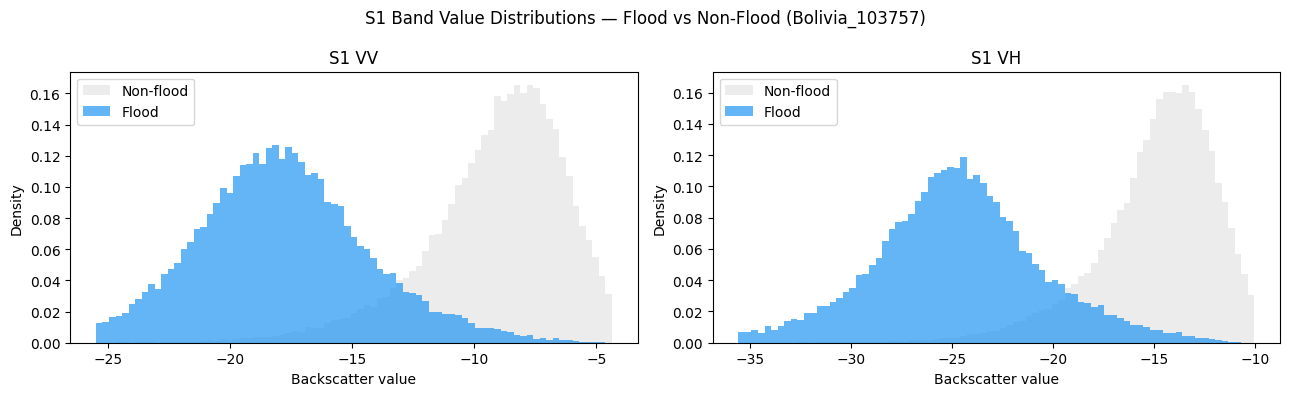

In [10]:
# S1: VV vs VH distribution — flood vs non-flood pixels
chip_id = "Bolivia_103757"
s1_path    = S1_HAND    / f"{chip_id}_S1Hand.tif"
label_path = LABEL_HAND / f"{chip_id}_LabelHand.tif"

with rasterio.open(s1_path) as src:
    vv = src.read(1).astype(float)
    vh = src.read(2).astype(float)
with rasterio.open(label_path) as src:
    lbl = src.read(1)

flood_mask    = lbl == 1
nonflood_mask = lbl == 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"S1 Band Value Distributions — Flood vs Non-Flood ({chip_id})", fontsize=12)

for ax, band, name in zip(axes, [vv, vh], ["VV", "VH"]):
    vals_flood    = band[flood_mask].ravel()
    vals_nonflood = band[nonflood_mask].ravel()

    lo = np.nanpercentile(band, 1); hi = np.nanpercentile(band, 99)
    bins = np.linspace(lo, hi, 80)

    ax.hist(vals_nonflood, bins=bins, alpha=0.6, color="#E0E0E0", label="Non-flood", density=True)
    ax.hist(vals_flood,    bins=bins, alpha=0.7, color="#2196F3", label="Flood",     density=True)
    ax.set_title(f"S1 {name}")
    ax.set_xlabel("Backscatter value")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Class Imbalance — Per Country Flood Ratio

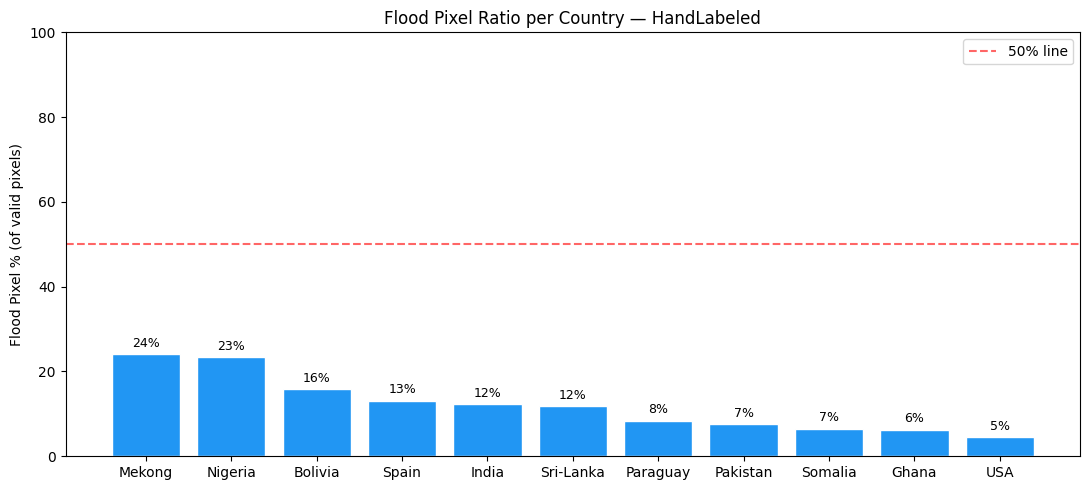

In [11]:
# Per-country flood ratio
country_flood   = defaultdict(int)
country_valid   = defaultdict(int)

for lf in sorted(LABEL_HAND.glob("*LabelHand.tif")):
    country = lf.stem.split("_")[0]
    with rasterio.open(lf) as src:
        lbl = src.read(1)
    country_flood[country]  += np.sum(lbl == 1)
    country_valid[country]  += np.sum(lbl >= 0)  # flood + non-flood

countries_sorted = sorted(country_flood.keys(),
                           key=lambda c: country_flood[c] / country_valid[c],
                           reverse=True)
flood_ratios = [country_flood[c] / country_valid[c] * 100 for c in countries_sorted]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(countries_sorted, flood_ratios, color="#2196F3", edgecolor="white")
ax.axhline(50, color="red", linestyle="--", alpha=0.6, label="50% line")
ax.set_ylabel("Flood Pixel % (of valid pixels)")
ax.set_title("Flood Pixel Ratio per Country — HandLabeled")
ax.set_ylim(0, 100)
ax.legend()

for bar, val in zip(bars, flood_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 8. EDA Summary & Key Takeaways for Modeling

### Key Findings

| Finding | Implication |
|---|---|
| **446 HandLabeled chips** with clean human-drawn masks | Enough for supervised training with augmentation |
| **4,384 WeaklyLabeled chips** available | Can be used for pretraining or semi-supervised learning |
| **S1 images: 2 bands (VV, VH), float32** | Normalize per-band using global mean/std from EDA |
| **S2 images: 13 bands, uint16** | Need scaling (divide by 10000); cloud issues possible |
| **Label values: -1 (invalid), 0 (non-flood), 1 (flood)** | Must mask out -1 pixels during loss computation |
| **Heavy class imbalance** (flood << non-flood) | Use **Dice Loss** or **Focal Loss** to handle imbalance |
| **Flood pixels cluster at low SAR backscatter** | S1 is highly informative; VV/VH both carry signal |
| **Chips are 512×512 pixels at 10m resolution** | No tiling needed — feed directly to model |

### Next Steps → Data Pipeline (Step 3)
- Build `PyTorch Dataset` class with `S1Hand` input + `LabelHand` target  
- Apply normalization, ignore invalid pixels in loss  
- Train/val/test split stratified by country  
- Add augmentation (horizontal/vertical flip, random rotation)